# Expfit notes 1: Initial guess for single exponential

## H1: Initial guess for a single exponential

\begin{align}
y(x)  &= a + b e^{c x} \\
y'(x) &= c b e^{c x}
\end{align}

**Given** two points $(x_1, y_1)$ and $(x_2, y_2)$ and their slopes $y_1'$ and $y_2'$
\begin{align}
y_1  - y_2  &= b (e^{c x_1} - e^{c x_2}) \\
y_1' - y_2' &= c b (e^{c x_1} - e^{c x_2}) \\
c &= \frac{y_1' - y_2'}{y_1 - y_2}
\end{align}
and
\begin{align}
a &= y_i - y'_i / c \\
b &= (y_i - a) / e^{c x_i}
\end{align}
for $i \in \{1, 2\}$

**Edge case**: if $y1 - y2 = 0$ we return $a=\text{mean}(y), b=0, c=0$.

### H1b: choosing $i$ for $a$ and $b$

For problems with $c$ of reasonable magnitude, we get the best results by setting $a$ and $b$ to the mean values for $i\in\{1, 2\}$.
But when $c$ is large (either positive or negative), choosing the wrong $i$ (or taking a mean) can give very poor results.
To remedy, we calculate $a_{i=1}, b{i=1}$, $a_{i=2}, b{i=2}$, $a_\text{mean}, b_\text{mean}$ and return whichever set gives the lowest RMSE compared to the data.

### H1c: dealing with flat lines

If the data is almost flat (whether noisy or clean), we get $b \rightarrow 0$ so that $c$ becomes unidentifiable, and typically very large.
To avoid returning huge $c$ (and very fast time constants), we check for "flatness" by calculting
calculate the RMSE of the data against a flat line $y = \text{mean}(y)$.
If this RMSE is 2 times lower than the lowest RMSE in H1b, we return $a=\text{mean}(y), b=0, c=0$.

## H2: Finding two points and their derivatives

To find $(x_1, y_1, y_1')$ and $(x_2, y_2, y_2')$ we select a segment $S_1$ at the start of the data, and a segment $S_2$ at the end of the data.

1. $x_i$ and $y_i$ are the mean of $t$ and $v$ on $S_i$
2. $y_i'$ is found by fitting a straight line to $S_i$ with linear least squares


### H2a: Finding segments $S_i$

To find segments that provide a good approximation for the slope, we select two initial segments, $S_1$ and $S_2$, from the full data set $S_0$.
These are chosen as the first ($S_1$) and second ($S_2$) half of $S_0$.
Next, we follow the procedure outlined below to iteratively shrink segment, stopping when the proposed next segment appears no longer meets certain criteria.

**Edge case**: If $S_0$ contains an odd number of points, we allow $S_1$ and $S_2$ to overlap in one point. This is advantageous for very sort $S_0$.

Linear least squares fits $L_i = \{s_i, o_i\}$ are performed for $i = 0, 1, 2$, where $s_i$ is a slope and $o_i$ is an offset.
For a time series (predominantly) containing an exponential, we expect that (1) the slopes $s_0$, $s_1$, and $s_2$ have the same sign; and (2) that the larger magnitude $s_i$ corresponds to the segment where the exponential changes most rapidly.

**Edge case**: If $s_1$ or $s_2$ has a different sign to $s_0$, this is assumed due to noise or some other corrupting signal. In this case, the slope is set to 0, and no further reduction of this segment is performed.

**Edge case**: If $s_1 = s_2 \neq 0$, this is clearly not an exponential, so we return initial estimate $a=o_0, b=s_0, c=0$.

**Magic numbers**: Using half the data initially, shrinking factor 0.5

#### Shrinking

To propose a new segment $\tilde{S}_i$, we halve the current segment. For $S_1$ we retain the initial half, for $S_2$ the second.

**Condition 1**. A linear least squares fit is then performed on the proposed segment.
If this has a different slope than the current segment, the proposal is rejected and the shrinking procedure ends.

**Condition 2**. Similarly, if this segment had the larger initial slope, we expect the shrinking to further increase it. If this is not the case (or vice versa for the other segment), the proposal is rejected and shrinking ends.

**Condition 3**. For a pure exponential we expect the ratio of the proposed slope over the previous slope $\tilde{s}_i / s_i$ to be the same each iteration (this works for halving, or reduction by any other _constant_ factor). 

**Assumption**. For condition 3, it matters that we "halve" each segment according to the sampled times, not the array indices. At the moment, this is not the case, so we need the extra assumption that the data are regularly spaced. If this assumption is not met, the method will halt early, and provided poorer initial estimates.

If all conditions are met, the proposal is accepted ($S_i \leftarrow \tilde{S}_i$, and a new proposal is made - until the proposal reaches or exceeds the minimum length.

**Magic number**: minimum length, 5.

### Demo: Initial guess for single exponential

First, create some data:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import expfit

In [2]:
rng = np.random.default_rng(2)

def f(x, a, b, c):
    return a + b * np.exp(c * x)

def fn(x, a, b, c, s):
    y = f(x, a, b, c)
    return y + (y[-1] - y[0]) * rng.normal(0, s, len(x))


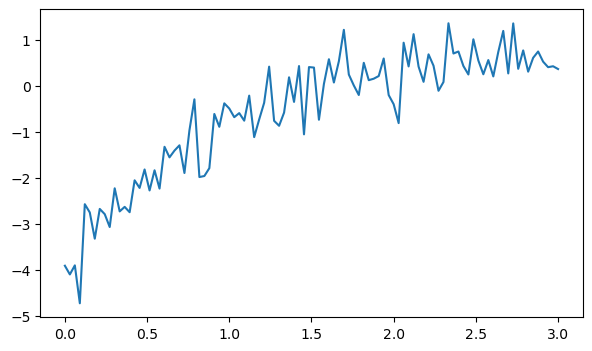

In [3]:
n = 100
s = 0.1
a, b, c = 1, -5, -1
x = np.linspace(0, 3, n)
y = fn(x, a, b, c, s)

fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot()
ax.plot(x, y, 's-' if n < 10 else '-')
plt.show()

Next, we demonstrate the shrinking procedure:

(0.58723015273076, -4.8670496188906105, -1.6219743285330097)

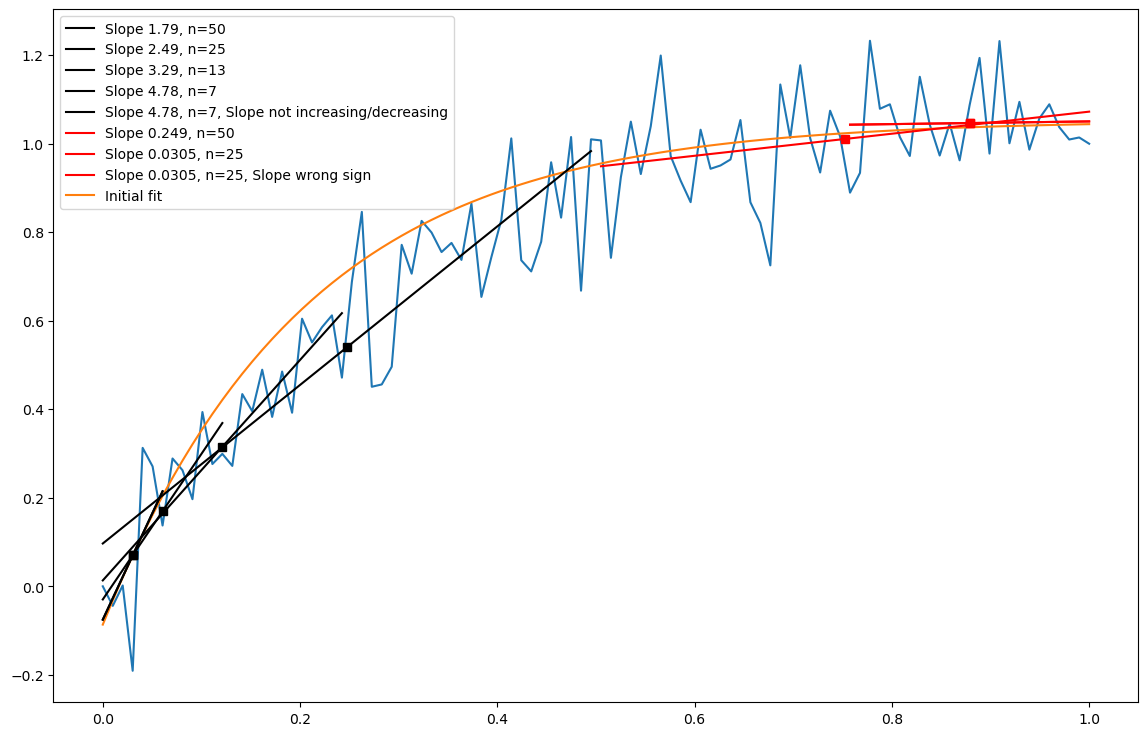

In [4]:
expfit.estimate_initial_single(x, y, plot=True)

Note that this shows the initial segment, the accepted proposals, and finally the rejected (and last) proposal.

Next, we show the segments selected this way on four different test cases:

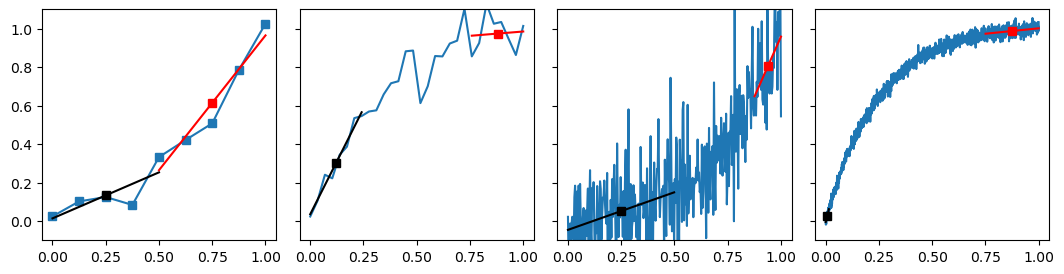

In [5]:
rng = np.random.default_rng(1)

tests = [
    (3, 2, 2, 0.07, 9),
    (-1, -2, -3, 0.08, 30),
    (-3, 5, 3, 0.2, 300),
    (4, -2, -4, 0.02, 1200),
]

def fnorm(x, a, b, c, s):
    # Version of fn that normalises y to [0, 1] (approximately)
    y = f(x, a, b, c)
    return (y - y[0]) / (y[-1] - y[0]) + rng.normal(0, s, len(x))

fig = plt.figure(figsize=(13, 3))
fig.subplots_adjust(wspace=0.1)
grd = fig.add_gridspec(1, 4)

for i, (a, b, c, s, n) in enumerate(tests):
    x = np.linspace(0, 1, n)
    y = fnorm(x, a, b, c, s)

    ax = fig.add_subplot(grd[i])
    ax.set_ylim(-0.1, 1.1)
    if i > 0:
        ax.set_yticklabels([])

    ax.plot(x, y, 's-' if n < 10 else '-')
    a0, b0, c0 = expfit.estimate_initial_single(x, y, axes=ax, transform=False)

plt.show()

Note that we have normalised the data here, causing all examples (note the different signs etc.) to look very similar.

Now, we run again showing the initial guesses.

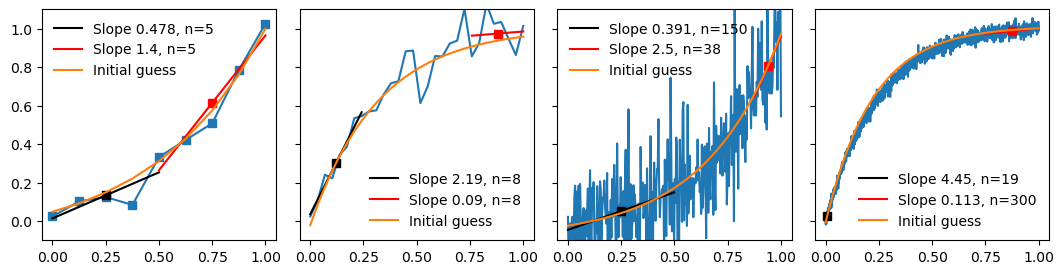

In [6]:
rng = np.random.default_rng(1)

fig = plt.figure(figsize=(13, 3))
fig.subplots_adjust(wspace=0.1)
grd = fig.add_gridspec(1, 4)
for i, (a, b, c, s, n) in enumerate(tests):
    x = np.linspace(0, 1, n)
    y = fnorm(x, a, b, c, s)

    ax = fig.add_subplot(grd[i])
    ax.plot(x, y, 's-' if n < 10 else '-')
    a0, b0, c0 = expfit.estimate_initial_single(x, y, axes=ax, transform=False)
    ax.plot(x, f(x, a0, b0, c0), label='Initial guess', zorder=10)
    ax.legend(frameon=False)
    ax.set_ylim(-0.1, 1.1)
    if i > 0:
        ax.set_yticklabels([])

plt.show()

## Some harder cases

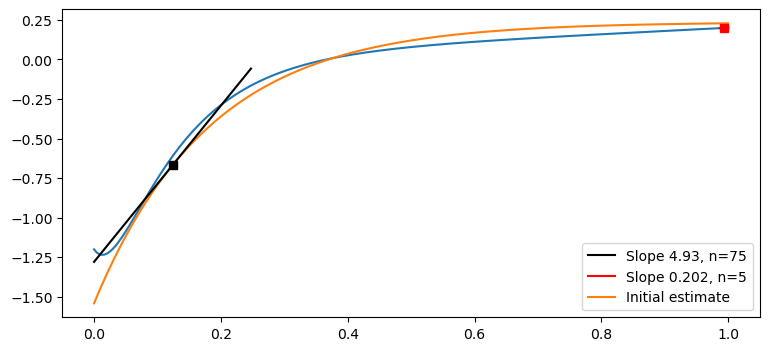

In [16]:
rng = np.random.default_rng(1)
a0, b0, c0 = 1, -2, -9
n = 300
x = np.linspace(0, 1, n)
y = a0 * np.zeros(x.shape)
y += b0 * np.exp(c0 * x)
y += 0.8 * np.exp(-30 * x)
y +=- -0.2 * x

def demo(x, y):
    #y = (y - y[0]) / (y[-1] - y[0])
    fig = plt.figure(figsize=(9, 4))
    ax = fig.add_subplot()
    ax.plot(x, y)
    a, b, c = expfit.estimate_initial_single(x, y, axes=ax, transform=False)
    ax.plot(x, a + b * np.exp(c * x), label='Initial estimate')
    ax.legend()

demo(x, y)
plt.show()

Next, a really big sine, causing the slopes at the start and end of the signal to exceed the expected slope.

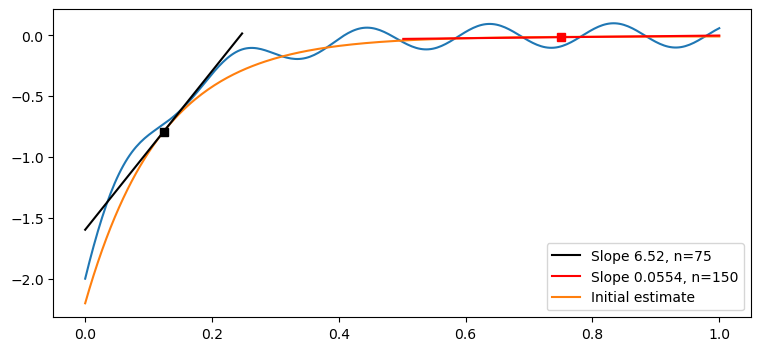

In [17]:
rng = np.random.default_rng(1)

a0, b0, c0 = 1, -2, -9
n = 300
x = np.linspace(0, 1, n)
y = a0 * np.zeros(x.shape)
y += b0 * np.exp(c0 * x)
y += 0.1 * np.sin(10.2 * np.pi * x)

demo(x, y)

A straight line with noise:

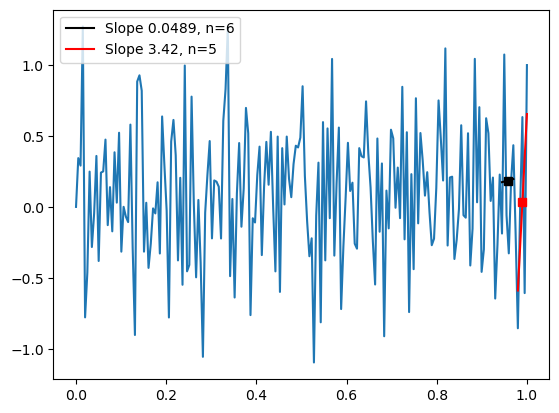

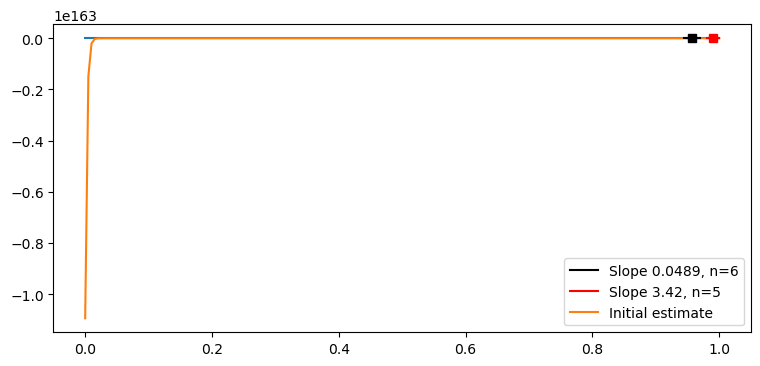

In [26]:
rng = np.random.default_rng(2)
n = 200
x = np.linspace(0, 1, n)
y = 3 * np.zeros(x.shape)
y += rng.normal(0, 1, x.shape)

y = (y - y[0]) / (y[-1] - y[0])

fig = plt.figure()
ax = fig.add_subplot()
ax.plot(x, y)
expfit.estimate_initial_single(x, y, axes=ax, transform=True)
ax.legend()
plt.show()

demo(x, y)

Note that the fit still won't be good: the start of the signal will distort the final result.

Next, a very contrived example, where a large sine causes both slopes to exceed the full signal slope:


In [ ]:
demo_fallbacks(x, y)
plt.show()

Next up, a straight line with noise:

And again, with a different random seed:

In [ ]:
rng = np.random.default_rng(1)
y = 3 + rng.normal(0, 1, x.shape)

demo_fallbacks(x, y)

### Autocorrelated noise

Finally, since we based the method of finding straight segments on autocorrelated residuals, we can try adding some to see if it breaks the method:

In [ ]:
a0, b0, c0 = 3, -4, -7
x = np.linspace(0, 1, 300)
y = a0 + b0 * np.exp(c0 * x)

# Add AR1 noise (https://pints.readthedocs.io/en/stable/noise_generators.html)
rng = np.random.default_rng(5)
rho, sigma = 0.9, 0.1
s = sigma * np.sqrt(1 - rho**2)
v = rng.normal(0, s, len(x))
v[0] = rng.uniform()
for t in range(1, len(x)):
    v[t] += rho * v[t - 1]
y += v

demo_fallbacks(x, y)

Note that the fallbacks here kicked in because the sign of the slope (red) was wrong.
The method has no problem finding segments of the signal that don't look particularly autocorrelated!